# Player Stats Analysis
Recibe un DataFrame con tracking data de jugadores y genera estadísticas y visualizaciones completas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter
import json
import cv2
import numpy as np

## 1. Cargar datos
Reemplaza esta celda con tu propio DataFrame. El CSV de ejemplo usa la estructura esperada.

In [3]:
df = pd.read_csv('../data/tennis_match_1/player_stats.csv')

print(f"Filas: {len(df)} | Jugadores: {df['player_id'].nunique()} | Frames: {df['frame'].nunique()}")
df.head()

Filas: 445 | Jugadores: 2 | Frames: 224


,frame,player_id,conf,x1,y1,x2,y2,cx,cy,width,height,mx,my,dist_meters,speed_kmh
0,1,1,0.9322,347.51,798.63,497.33,1052.82,422.42,925.72,149.83,254.20,1.1967,22.9777,NaN,NaN
1,1,2,0.7879,1044.55,158.01,1099.86,288.80,1072.20,223.41,55.31,130.80,6.5820,-4.3578,NaN,NaN
2,2,1,0.9276,347.72,800.58,496.36,1054.03,422.04,927.30,148.64,253.45,1.1967,22.9777,0.0000,0.00
3,2,2,0.7407,1047.03,162.72,1102.28,288.71,1074.66,225.71,55.25,125.99,6.6817,-4.1597,0.2218,23.95
4,3,1,0.8734,347.79,801.25,495.81,1054.36,421.80,927.80,148.02,253.11,1.1967,22.9777,0.0000,0.00


In [4]:
# Posiciones normalizadas de cada keypoint en la cancha real
# (x, y) en metros, origen en kp0 (esquina superior izquierda)
# Cancha dobles: 23.77m largo x 10.97m ancho
_COURT_WIDTH  = 10.97
_COURT_LENGTH = 23.77
_SERVICE_BOX  = 6.40   # distancia de la red a la línea de servicio
_DOUBLES_ALLY = 1.37   # ancho del pasillo de dobles

_KP_REAL_COORDS = {
    # Esquinas externas
    0:  (0.0,                        0.0),
    1:  (_COURT_WIDTH,               0.0),
    2:  (0.0,                        _COURT_LENGTH),
    3:  (_COURT_WIDTH,               _COURT_LENGTH),
    # Líneas de dobles internas (separación de pasillo)
    4:  (_DOUBLES_ALLY,              0.0),
    5:  (_DOUBLES_ALLY,              _COURT_LENGTH),
    6:  (_COURT_WIDTH - _DOUBLES_ALLY, 0.0),
    7:  (_COURT_WIDTH - _DOUBLES_ALLY, _COURT_LENGTH),
    # Líneas de servicio
    8:  (_DOUBLES_ALLY,              _COURT_LENGTH / 2 - _SERVICE_BOX),
    9:  (_COURT_WIDTH - _DOUBLES_ALLY, _COURT_LENGTH / 2 - _SERVICE_BOX),
    10: (_DOUBLES_ALLY,              _COURT_LENGTH / 2 + _SERVICE_BOX),
    11: (_COURT_WIDTH - _DOUBLES_ALLY, _COURT_LENGTH / 2 + _SERVICE_BOX),
    # Centro de la red
    12: (_COURT_WIDTH / 2,           _COURT_LENGTH / 2 - _SERVICE_BOX),
    13: (_COURT_WIDTH / 2,           _COURT_LENGTH / 2 + _SERVICE_BOX),
}


class MiniCourt:
    """
    Dibuja una minicancha cenital en una esquina del frame,
    proyectando jugadores usando homografía desde los keypoints del court.
    """

    # Colores jugadores (mismos que PlayerTracker para consistencia)
    _PLAYER_COLORS = [
        (255, 100, 0), (0, 200, 255), (0, 255, 100),
        (200, 0, 255), (255, 200, 0), (0, 100, 255),
    ]

    def __init__(
        self,
        origin: tuple[int, int] = (20, None),  # None se calcula en set_frame_size
        width:  int = 150,
        height: int = 280,
        margin: int = 20,
    ):
        self.width   = width
        self.height  = height
        self.margin  = margin
        self._origin = origin          # (x, y) esquina superior izquierda del rectángulo
        self._H      = None            # homografía imagen minicancha

    def set_frame_size(self, frame_height: int) -> None:
        """Calcula la posición vertical si origin[1] es None (anclar al fondo)."""
        x, y = self._origin
        if y is None:
            y = frame_height - self.height - self.margin
        self._origin = (x, y)

    def set_court_reference(self, kps: np.ndarray) -> None:
        """
        Calcula la homografía entre los keypoints de imagen y la minicancha.
        Debe llamarse una vez con los keypoints del primer frame.
        """
        ox, oy = self._origin
        pad    = self.margin

        # Escala metros pixels dentro del rectángulo de la minicancha
        scale_x = (self.width - 2 * pad) / _COURT_WIDTH   # pixels_minicancha / metro
        scale_y = (self.height - 2 * pad) / _COURT_LENGTH

        # Puntos fuente (imagen) y destino (minicancha) para la homografía
        src_pts, dst_pts = [], []
        for kp_idx, (rx, ry) in _KP_REAL_COORDS.items():
            ix = kps[kp_idx * 2]
            iy = kps[kp_idx * 2 + 1]
            mx = ox + pad + rx * scale_x
            my = oy + pad + ry * scale_y
            src_pts.append([ix, iy])
            dst_pts.append([mx, my])

        src = np.array(src_pts, dtype=np.float32)
        dst = np.array(dst_pts, dtype=np.float32)
        self._H, _ = cv2.findHomography(src, dst, cv2.RANSAC)

        # Factor de conversión: pixels de minicancha -> metros reales
        # Usamos el ancho de la cancha (kp0 -> kp1) como referencia
        # ya que es la dimensión más estable horizontalmente
        pad     = self.margin
        ox, oy  = self._origin
        self._meters_per_pixel_x = 1.0 / scale_x  # metros / pixel_minicancha
        self._meters_per_pixel_y = 1.0 / scale_y

    def project_point(self, x: float, y: float) -> tuple[int, int] | None:
        """Proyecta un punto de imagen a coordenadas de minicancha."""
        if self._H is None:
            return None
        pt  = np.array([[[x, y]]], dtype=np.float32)
        out = cv2.perspectiveTransform(pt, self._H)
        return int(out[0][0][0]), int(out[0][0][1])
    
    def project_to_meters(self, x: float, y: float) -> tuple[float, float] | None:
        """
        Proyecta un punto de imagen a coordenadas reales en metros.
        Primero proyecta a minicancha, luego aplica factor de conversión.
        """
        pt_px = self.project_point(x, y)
        if pt_px is None:
            return None
    
        ox, oy = self._origin
        pad    = self.margin
    
        # Restar origen y padding para obtener coordenadas relativas al court
        mx = (pt_px[0] - ox - pad) * self._meters_per_pixel_x
        my = (pt_px[1] - oy - pad) * self._meters_per_pixel_y
        
        return round(mx, 4), round(my, 4)
    
    def distance_in_meters(self, x0: float, y0: float, x1: float, y1: float) -> float | None:
        """
        Calcula la distancia euclidiana en metros entre dos puntos de imagen.
        Útil para velocidad de pelota y distancia recorrida por jugadores.
        """
        p0 = self.project_to_meters(x0, y0)
        p1 = self.project_to_meters(x1, y1)
        if p0 is None or p1 is None:
            return None
        return round(np.sqrt((p1[0] - p0[0])**2 + (p1[1] - p0[1])**2), 4)

    def draw(
        self,
        frame:       np.ndarray,
        player_rows: list[dict],
        ball_row:    dict | None = None,   
    ) -> None:
        """
        Dibuja la minicancha, proyecta jugadores y pelota (in-place).
        """
        self._draw_court(frame)
        self._draw_players(frame, player_rows)
        if ball_row is not None:
            self._draw_ball(frame, ball_row)

    def _draw_ball(self, frame: np.ndarray, ball_row: dict) -> None:
        """Proyecta y dibuja la pelota en la minicancha."""
        if not ball_row.get("ball_detected") and not ball_row.get("interpolated"):
            return  # empty row, nada que dibujar

        cx = ball_row.get("cx")
        cy = ball_row.get("cy")
        if cx is None or cy is None:
            return

        pt = self.project_point(cx, cy)
        if pt is None:
            return
        
        cv2.circle(frame, pt, radius=5, color=(0, 255, 255), thickness=-1)

    #  Helpers  

    def _draw_court(self, frame: np.ndarray) -> None:
        """Dibuja el rectángulo y las líneas de la cancha."""
        ox, oy = self._origin
        pad    = self.margin
        scale_x = (self.width  - 2 * pad) / _COURT_WIDTH
        scale_y = (self.height - 2 * pad) / _COURT_LENGTH

        def mp(rx, ry):  # metros pixel en minicancha
            return (
                int(ox + pad + rx * scale_x),
                int(oy + pad + ry * scale_y),
            )

        # Fondo semitransparente
        overlay = frame.copy()
        cv2.rectangle(
            overlay,
            (ox, oy), (ox + self.width, oy + self.height),
            (30, 30, 30), -1,
        )
        cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

        c = (200, 200, 200)  # color líneas
        t = 1                # grosor

        # Borde externo (dobles)
        cv2.rectangle(frame, mp(0, 0), mp(_COURT_WIDTH, _COURT_LENGTH), c, t)

        # Líneas de singles (pasillos)
        cv2.line(frame, mp(_DOUBLES_ALLY, 0),              mp(_DOUBLES_ALLY, _COURT_LENGTH),              c, t)
        cv2.line(frame, mp(_COURT_WIDTH - _DOUBLES_ALLY, 0), mp(_COURT_WIDTH - _DOUBLES_ALLY, _COURT_LENGTH), c, t)

        # Red (centro)
        net_y = _COURT_LENGTH / 2
        cv2.line(frame, mp(0, net_y), mp(_COURT_WIDTH, net_y), (100, 200, 255), 2)

        # Líneas de servicio
        sv_top = net_y - _SERVICE_BOX
        sv_bot = net_y + _SERVICE_BOX
        cv2.line(frame, mp(_DOUBLES_ALLY, sv_top), mp(_COURT_WIDTH - _DOUBLES_ALLY, sv_top), c, t)
        cv2.line(frame, mp(_DOUBLES_ALLY, sv_bot), mp(_COURT_WIDTH - _DOUBLES_ALLY, sv_bot), c, t)

        # Centro de la línea de servicio (T)
        cv2.line(frame, mp(_COURT_WIDTH / 2, sv_top), mp(_COURT_WIDTH / 2, sv_bot), c, t)

    def _draw_players(self, frame: np.ndarray, player_rows: list[dict]) -> None:
        """Proyecta y dibuja cada jugador en la minicancha."""
        for row in player_rows:
            pt = self.project_point(row["cx"], row["cy"])
            if pt is None:
                continue
            pid   = row["player_id"]
            color = self._PLAYER_COLORS[pid % len(self._PLAYER_COLORS)]
            cv2.circle(frame, pt, radius=6, color=color, thickness=-1)
            cv2.putText(
                frame, f"P{pid}",
                (pt[0] + 7, pt[1] + 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA,
            )

In [5]:
with open("../data/tennis_match_1/result.json") as f:
    state = json.load(f)
    
FPS = state["video_data"]["fps"]
origin = state['mini_court_homography_state']['origin']
frame_height = state['mini_court_homography_state']['frame_height']

mini_court = MiniCourt(origin=tuple(origin))
mini_court.set_frame_size(frame_height)

kps = np.array(state['mini_court_homography_state']["kps"], dtype=np.float32)

mini_court.set_court_reference(kps)

In [6]:
kps

array([ 583.5761 ,  285.398  , 1399.4861 ,  284.64185,  227.4589 ,
        964.61   , 1741.2485 ,  960.8363 ,  684.41394,  284.69876,
        415.58276,  963.08   , 1296.5673 ,  284.66074, 1555.0704 ,
        960.94586,  647.89606,  380.19016, 1330.48   ,  379.2586 ,
        510.56137,  724.38025, 1461.5251 ,  723.2181 ,  987.23376,
        379.89435,  986.083  ,  723.3773 ], dtype=float32)

In [7]:
df = df.dropna(subset=['dist_meters', 'speed_kmh'])

## 2. Resumen estadístico por jugador

In [8]:
SPRINT_THRESHOLD_KMH = 20.0   # umbral para contar un sprint
SPEED_BINS = [0, 5, 10, 15, 20, 35]
SPEED_LABELS = ['0-5', '5-10', '10-15', '15-20', '>20']
PLAYER_COLORS = ['#7F77DD', '#1D9E75', '#D85A30', '#378ADD']

def get_color(i):
    return PLAYER_COLORS[i % len(PLAYER_COLORS)]

def summarize(df):
    rows = []
    for pid, grp in df.groupby('player_id'):
        valid = grp.dropna(subset=['speed_kmh', 'dist_meters'])
        # sprints: grupos de frames consecutivos con speed > umbral
        above = (valid['speed_kmh'] > SPRINT_THRESHOLD_KMH).astype(int)
        sprints = (above.diff() == 1).sum()
        rows.append({
            'player_id':      pid,
            'dist_total_m':   round(valid['dist_meters'].sum(), 2),
            'speed_max_kmh':  round(valid['speed_kmh'].max(), 2),
            'speed_avg_kmh':  round(valid['speed_kmh'].mean(), 2),
            'speed_med_kmh':  round(valid['speed_kmh'].median(), 2),
            'sprints':        int(sprints),
            'frames_moving':  int((valid['speed_kmh'] > 1).sum()),
            'frames_total':   int(len(grp)),
        })
    summary = pd.DataFrame(rows)
    summary['pct_moving'] = (summary['frames_moving'] / summary['frames_total'] * 100).round(1)
    return summary

summary = summarize(df)
display(summary)

,player_id,dist_total_m,speed_max_kmh,speed_avg_kmh,speed_med_kmh,sprints,frames_moving,frames_total,pct_moving
0,1,16.09,33.86,7.83,10.69,14,127,222,57.2
1,2,19.83,33.85,10.20,10.70,26,145,210,69.0


## 3. Velocidad en el tiempo

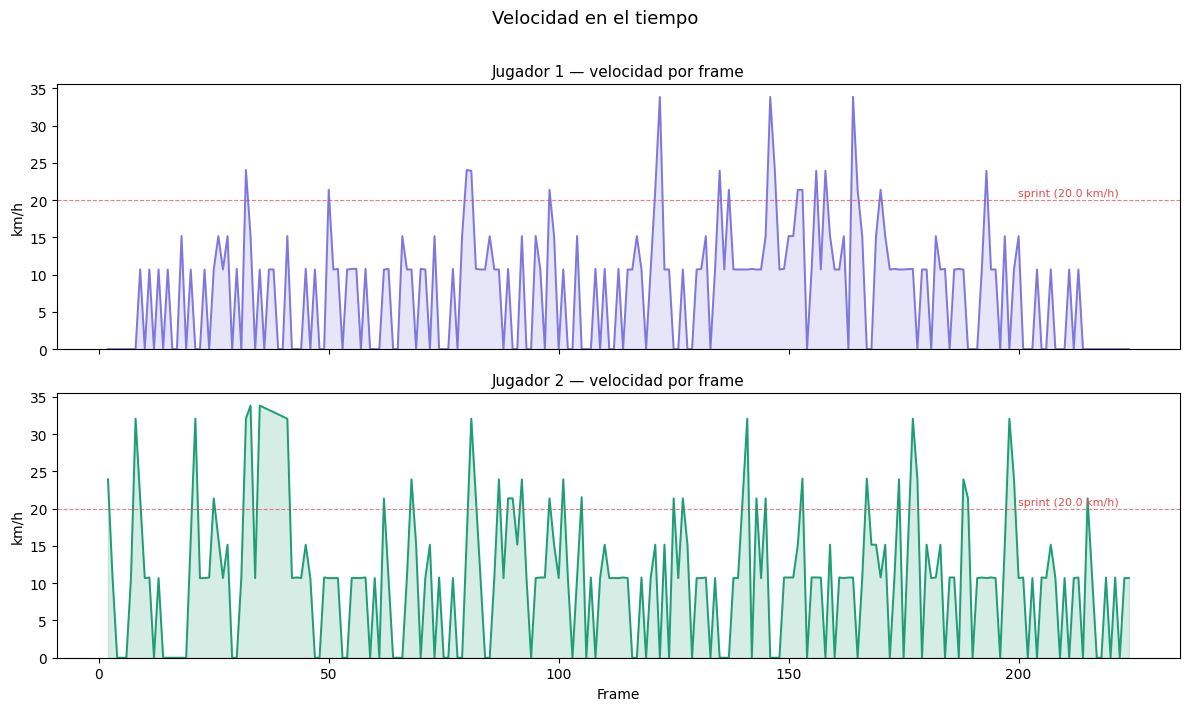

In [9]:
players = sorted(df['player_id'].unique())
fig, axes = plt.subplots(len(players), 1, figsize=(12, 3.5 * len(players)), sharex=True)
if len(players) == 1:
    axes = [axes]

for ax, pid in zip(axes, players):
    grp = df[df['player_id'] == pid].sort_values('frame')
    color = get_color(players.index(pid))
    ax.fill_between(grp['frame'], grp['speed_kmh'].fillna(0), alpha=0.18, color=color)
    ax.plot(grp['frame'], grp['speed_kmh'], color=color, linewidth=1.4, label=f'J{pid}')
    ax.axhline(SPRINT_THRESHOLD_KMH, color='#E24B4A', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.text(grp['frame'].max() * 0.99, SPRINT_THRESHOLD_KMH + 0.5,
            f'sprint ({SPRINT_THRESHOLD_KMH} km/h)', ha='right', fontsize=8, color='#E24B4A')
    ax.set_ylabel('km/h', fontsize=10)
    ax.set_title(f'Jugador {pid} — velocidad por frame', fontsize=11, pad=6)
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel('Frame', fontsize=10)
fig.suptitle('Velocidad en el tiempo', fontsize=13, y=1.01, fontweight='500')
plt.tight_layout()
plt.show()

## 4. Distribución de velocidad por rangos

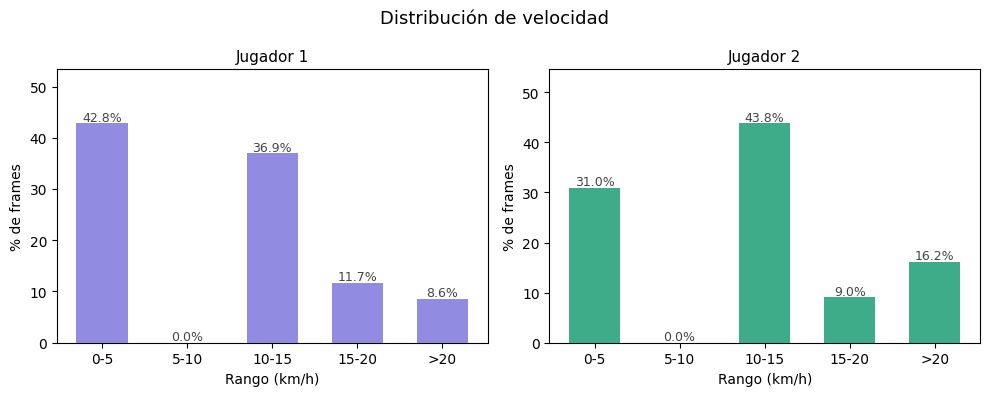

In [10]:
fig, axes = plt.subplots(1, len(players), figsize=(5 * len(players), 4), sharey=False)
if len(players) == 1:
    axes = [axes]

for ax, pid in zip(axes, players):
    grp = df[(df['player_id'] == pid)].dropna(subset=['speed_kmh'])
    counts, _ = np.histogram(grp['speed_kmh'], bins=SPEED_BINS)
    pcts = counts / counts.sum() * 100
    color = get_color(players.index(pid))
    bars = ax.bar(SPEED_LABELS, pcts, color=color, alpha=0.85, width=0.6, zorder=3)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=9, color='#444')
    ax.set_xlabel('Rango (km/h)', fontsize=10)
    ax.set_ylabel('% de frames', fontsize=10)
    ax.set_title(f'Jugador {pid}', fontsize=11)
    ax.set_ylim(0, max(pcts) * 1.2 + 2)

fig.suptitle('Distribución de velocidad', fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

## 5. Distancia acumulada

In [11]:
def plot_cumulative_distance(
    df: pd.DataFrame,
    figsize: tuple = (12, 4),
    fps: float = None,
) -> pd.DataFrame:
    """
    Grafica la distancia acumulada por jugador a lo largo del partido
    y retorna un DataFrame con los datos calculados.

    Parámetros
    ----------
    df      : DataFrame con columnas dist_meters, player_id, frame
    figsize : tamaño de la figura
    fps     : si se provee, el eje X muestra segundos en lugar de frames

    Retorna
    -------
    DataFrame con columnas: frame, player_id, cumul_dist, [seconds]
    """
    players = sorted(df['player_id'].dropna().unique().astype(int).tolist())

    results = []
    fig, ax = plt.subplots(figsize=figsize)

    for pid in players:
        grp = (df[df['player_id'] == pid]
               .sort_values('frame')
               .copy())

        grp['cumul_dist'] = grp['dist_meters'].fillna(0).cumsum()

        x = grp['frame']
        x_label = 'Frame'
        if fps:
            grp['seconds'] = grp['frame'] / fps
            x = grp['seconds']
            x_label = 'Tiempo (s)'

        color = PLAYER_COLORS[(pid - 1) % len(PLAYER_COLORS)]
        total = grp['cumul_dist'].iloc[-1]

        ax.plot(x, grp['cumul_dist'],
                color=color, linewidth=2,
                label=f'Jugador {pid}  ({total:.1f} m)')

        # Anotación del total al final de la línea
        ax.annotate(
            f"{total:.1f} m",
            xy=(x.iloc[-1], total),
            xytext=(6, 0), textcoords='offset points',
            fontsize=8.5, color=color, va='center', fontweight='600'
        )

        results.append(grp[['frame', 'player_id', 'cumul_dist']
                            + (['seconds'] if fps else [])])

    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel('Distancia acumulada (m)', fontsize=10)
    ax.set_title('Distancia acumulada a lo largo del partido',
                 fontsize=12, fontweight='600')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    plt.tight_layout()
    plt.show()

    return pd.concat(results, ignore_index=True)

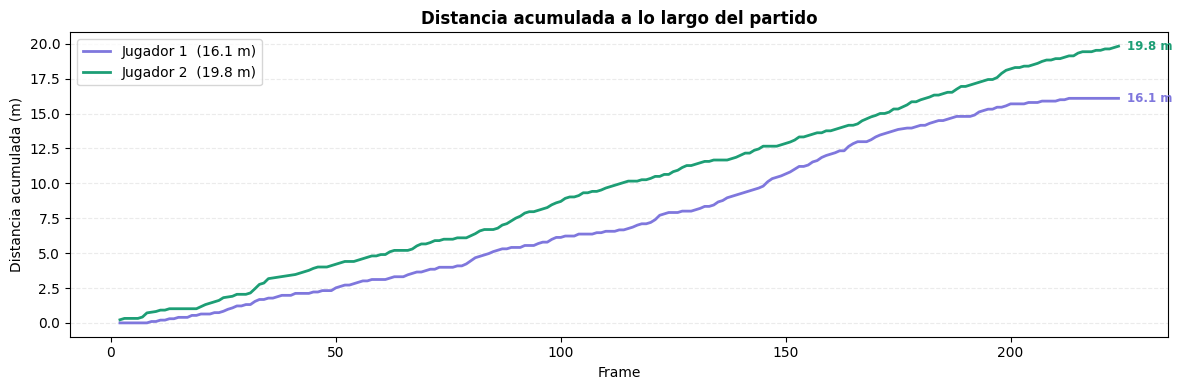

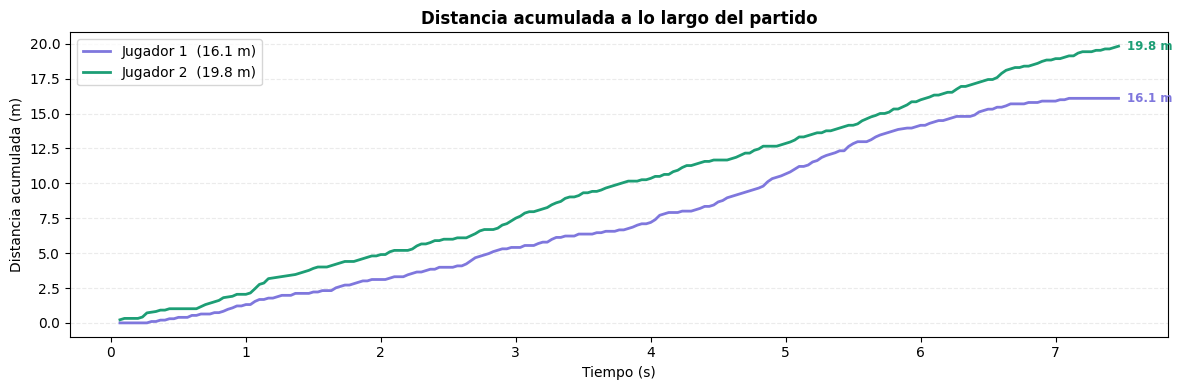

player_id
1    16.0914
2    19.8301
Name: cumul_dist, dtype: float64

In [12]:
# Eje X en frames
result_df = plot_cumulative_distance(df)

# Eje X en segundos (si tienes 30 fps)
result_df = plot_cumulative_distance(df, fps=FPS)

# Revisar el DataFrame retornado
result_df.groupby('player_id')['cumul_dist'].max()

## 6. Comparación entre jugadores

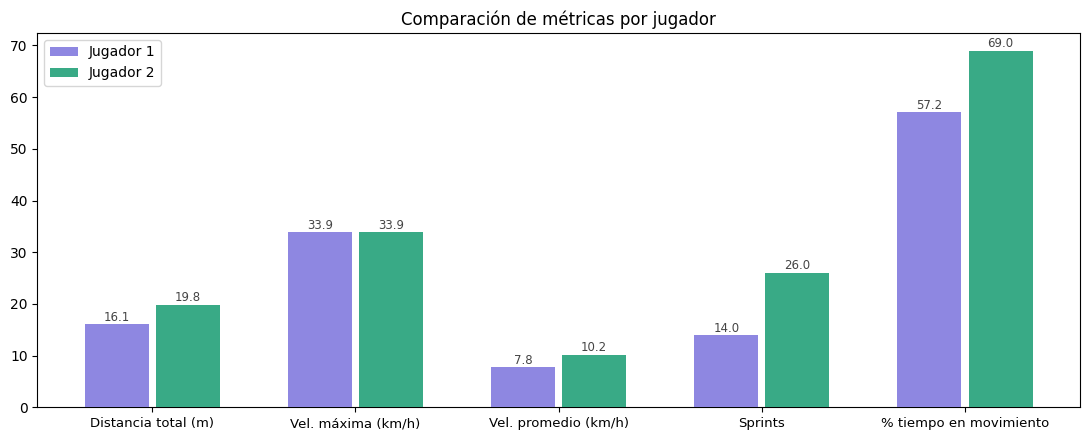

In [13]:
metrics = {
    'dist_total_m':  'Distancia total (m)',
    'speed_max_kmh': 'Vel. máxima (km/h)',
    'speed_avg_kmh': 'Vel. promedio (km/h)',
    'sprints':       'Sprints',
    'pct_moving':    '% tiempo en movimiento',
}

n_metrics = len(metrics)
x = np.arange(n_metrics)
width = 0.7 / len(players)

fig, ax = plt.subplots(figsize=(11, 4.5))

for i, pid in enumerate(players):
    row = summary[summary['player_id'] == pid].iloc[0]
    vals = [row[m] for m in metrics]
    color = get_color(i)
    offset = (i - (len(players)-1)/2) * width
    bars = ax.bar(x + offset, vals, width * 0.9, label=f'Jugador {pid}', color=color, alpha=0.88, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.1f}', ha='center', fontsize=8.5, color='#444')

ax.set_xticks(x)
ax.set_xticklabels(list(metrics.values()), fontsize=9.5)
ax.set_title('Comparación de métricas por jugador', fontsize=12, fontweight='500')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Aceleración (cambio de velocidad entre frames)

In [14]:
def plot_acceleration(
    df: pd.DataFrame,
    fps: float = 30.0,
    smooth_window: int = 5,
    figsize: tuple = (12, 8),
) -> pd.DataFrame:
    """
    Calcula y grafica la aceleración de cada jugador (cambio de velocidad entre frames).

    Parámetros
    ----------
    df            : DataFrame con columnas speed_kmh, player_id, frame
    fps           : frames por segundo del video (para convertir a m/s²)
    smooth_window : ventana de suavizado (rolling mean), 1 = sin suavizado
    figsize       : tamaño de la figura

    Retorna
    -------
    DataFrame con columnas: frame, player_id, speed_kmh, accel_ms2
    """
    players = sorted(df['player_id'].dropna().unique().astype(int).tolist())
    results = []

    # ── Calcular aceleración ──────────────────────────────────────────────────
    for pid in players:
        grp = (df[df['player_id'] == pid]
               .sort_values('frame')
               .copy())

        speed_ms = grp['speed_kmh'].fillna(0) / 3.6          # km/h → m/s
        dt       = 1.0 / fps                                  # segundos por frame

        grp['accel_ms2'] = speed_ms.diff() / dt               # m/s²
        grp['accel_ms2'] = (grp['accel_ms2']
                            .rolling(smooth_window, center=True, min_periods=1)
                            .mean())
        results.append(grp[['frame', 'player_id', 'speed_kmh', 'accel_ms2']])

    result_df = pd.concat(results, ignore_index=True)

    #  Plot 
    fig, axes = plt.subplots(
        3, 1, figsize=figsize,
        gridspec_kw={'height_ratios': [2, 2, 1]},
        sharex=True
    )

    ax_accel, ax_speed, ax_bar = axes

    for pid in players:
        grp   = result_df[result_df['player_id'] == pid]
        color = PLAYER_COLORS[(pid - 1) % len(PLAYER_COLORS)]

        #  Panel 1: aceleración 
        accel = grp['accel_ms2'].values
        frames = grp['frame'].values

        # Colorear positivo (acelera) vs negativo (frena)
        ax_accel.fill_between(frames, accel, 0,
                              where=(accel >= 0),
                              alpha=0.25, color=color)
        ax_accel.fill_between(frames, accel, 0,
                              where=(accel < 0),
                              alpha=0.25, color=color)
        ax_accel.plot(frames, accel,
                      color=color, linewidth=1.2,
                      label=f'Jugador {pid}')

        #  Panel 2: velocidad 
        ax_speed.plot(grp['frame'], grp['speed_kmh'].fillna(0),
                      color=color, linewidth=1.2, alpha=0.85,
                      label=f'Jugador {pid}')

        #  Panel 3: barras de estadísticas 
        a_max  = grp['accel_ms2'].max()
        a_min  = grp['accel_ms2'].min()
        a_std  = grp['accel_ms2'].std()

        offset = (pid - 1) * 0.25
        ax_bar.barh(offset,       a_max, height=0.2,  color=color, alpha=0.85,
                    label=f'P{pid} máx aceleración')
        ax_bar.barh(offset + 0.22, abs(a_min), height=0.2, color=color, alpha=0.4,
                    label=f'P{pid} máx frenada')

    #  Formato panel aceleración 
    ax_accel.axhline(0, color='white', linewidth=0.8, alpha=0.4, linestyle='--')
    ax_accel.set_ylabel('Aceleración (m/s²)', fontsize=9)
    ax_accel.set_title('Aceleración por frame', fontsize=10, fontweight='600')
    ax_accel.legend(fontsize=9, loc='upper right')
    ax_accel.grid(axis='y', alpha=0.15, linestyle='--')

    #  Formato panel velocidad 
    ax_speed.set_ylabel('Velocidad (km/h)', fontsize=9)
    ax_speed.set_title('Velocidad por frame', fontsize=10, fontweight='600')
    ax_speed.legend(fontsize=9, loc='upper right')
    ax_speed.grid(axis='y', alpha=0.15, linestyle='--')

    #  Formato panel barras 
    ax_bar.set_yticks([p * 0.25 + 0.1 for p in range(len(players))])
    ax_bar.set_yticklabels([f'J{p}' for p in players], fontsize=8)
    ax_bar.set_xlabel('Frame', fontsize=9)
    ax_bar.set_title('Máx aceleración (opaco) vs máx frenada (transparente)  [m/s²]',
                     fontsize=9, fontweight='500')
    ax_bar.grid(axis='x', alpha=0.15, linestyle='--')
    ax_bar.axvline(0, color='white', linewidth=0.6, alpha=0.4)

    fig.suptitle('Análisis de aceleración comparativo',
                 fontsize=13, fontweight='600', y=1.01)
    plt.tight_layout()
    plt.show()

    #  Resumen por consola 
    print("\n Resumen de aceleración ")
    for pid in players:
        grp = result_df[result_df['player_id'] == pid]
        print(f"  Jugador {pid}:")
        print(f"    Máx aceleración : {grp['accel_ms2'].max():+.2f} m/s²")
        print(f"    Máx frenada     : {grp['accel_ms2'].min():+.2f} m/s²")
        print(f"    Desv. estándar  : {grp['accel_ms2'].std():.2f} m/s²")

    return result_df

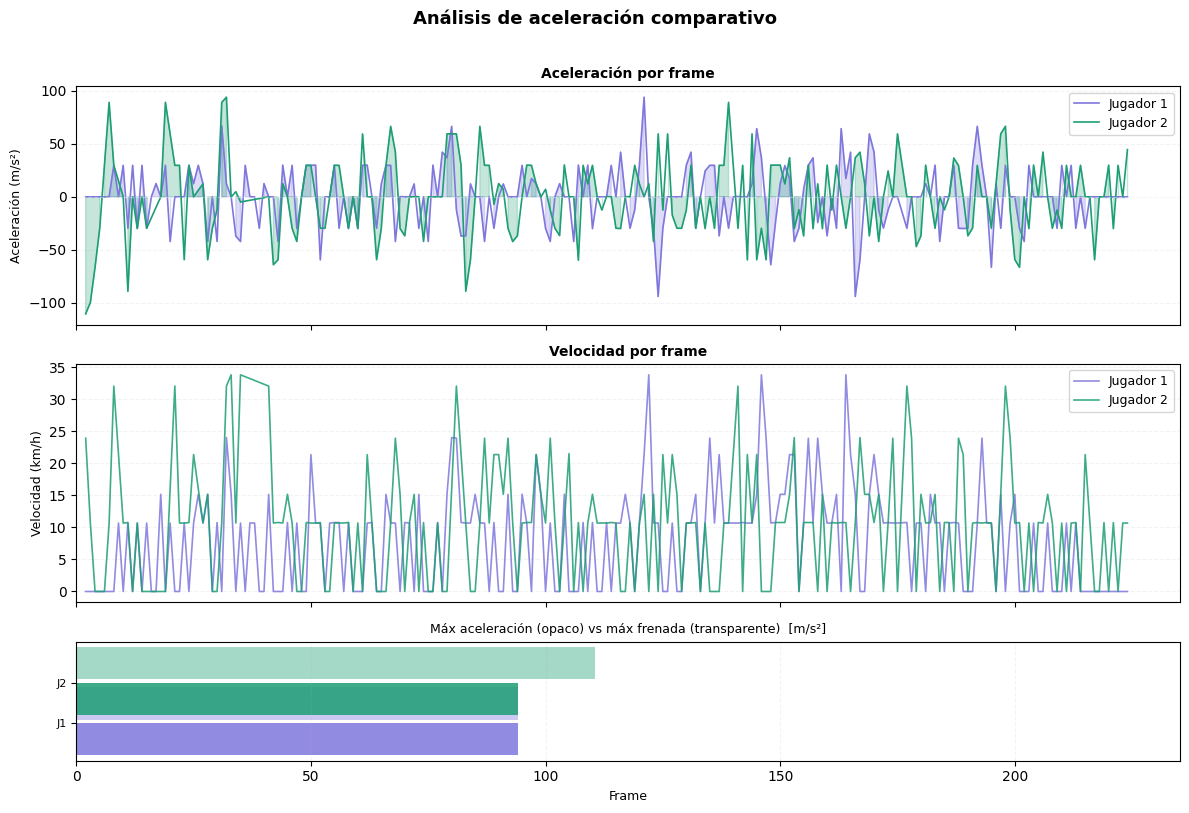


 Resumen de aceleración 
  Jugador 1:
    Máx aceleración : +94.06 m/s²
    Máx frenada     : -94.06 m/s²
    Desv. estándar  : 28.16 m/s²
  Jugador 2:
    Máx aceleración : +94.03 m/s²
    Máx frenada     : -110.50 m/s²
    Desv. estándar  : 35.95 m/s²


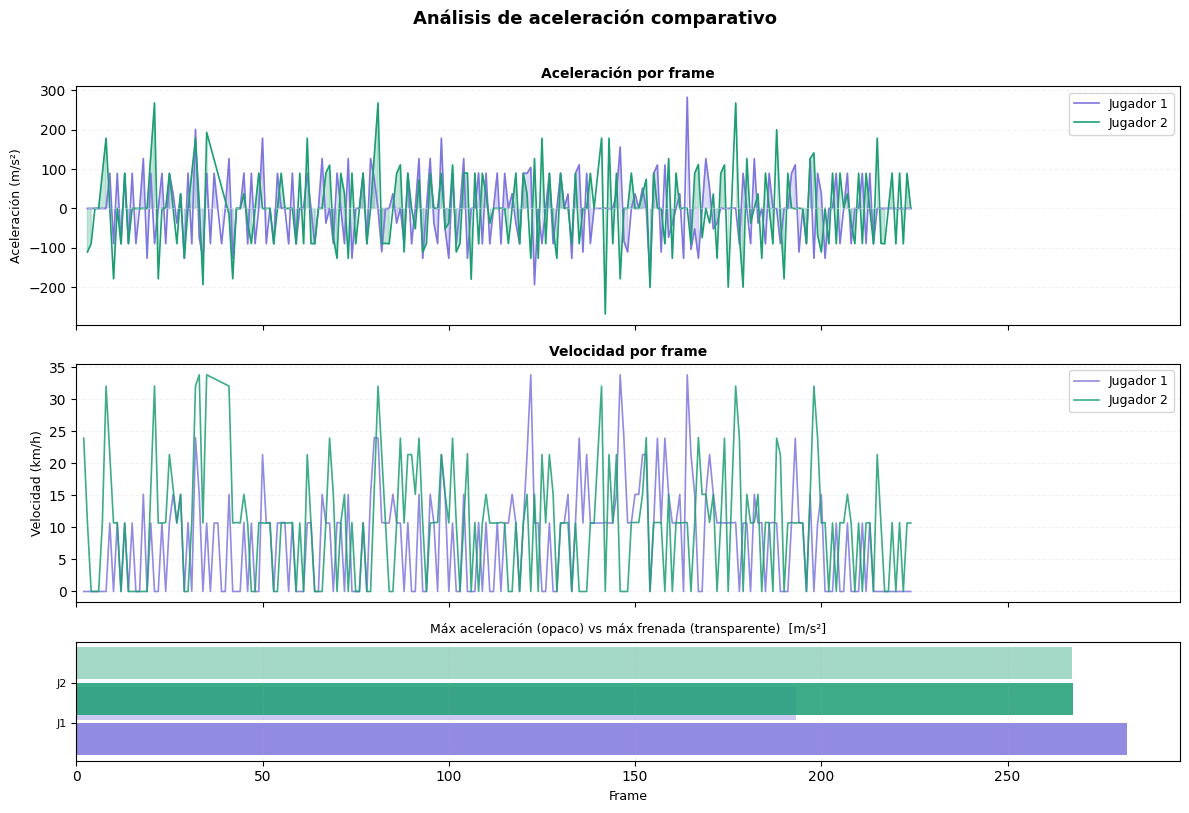


 Resumen de aceleración 
  Jugador 1:
    Máx aceleración : +282.17 m/s²
    Máx frenada     : -193.08 m/s²
    Desv. estándar  : 81.63 m/s²
  Jugador 2:
    Máx aceleración : +267.50 m/s²
    Máx frenada     : -267.42 m/s²
    Desv. estándar  : 97.04 m/s²


In [15]:
# Con suavizado recomendado para pocos frames
accel_df = plot_acceleration(df, fps=FPS, smooth_window=3)

# Sin suavizado (más ruidoso pero más fiel)
accel_df = plot_acceleration(df, fps=FPS, smooth_window=1)

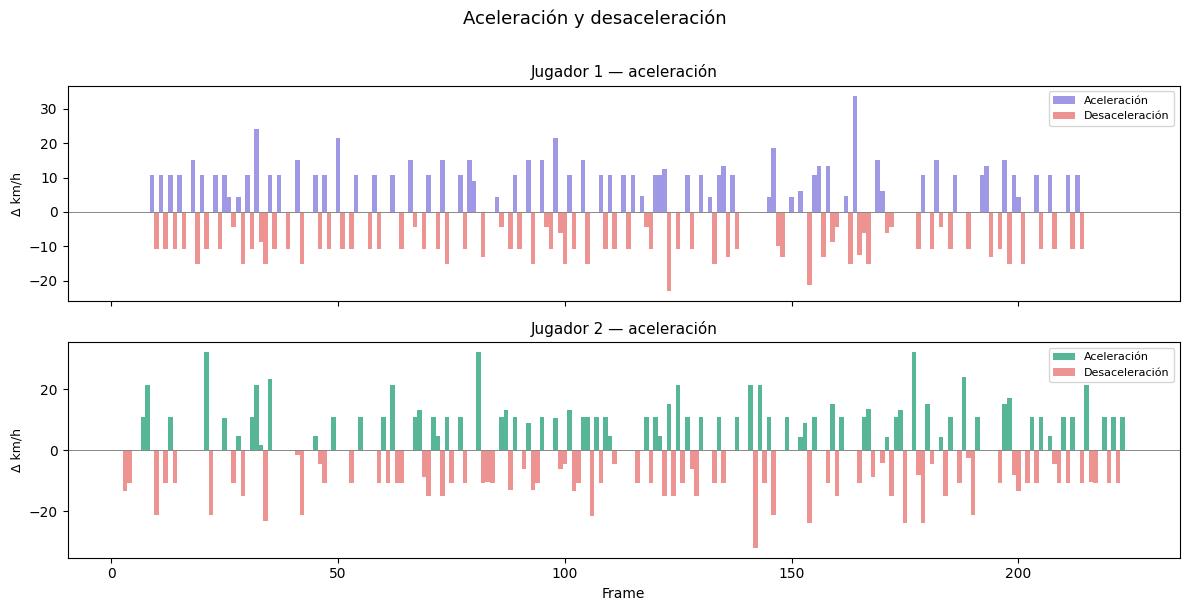

In [16]:
fig, axes = plt.subplots(len(players), 1, figsize=(12, 3 * len(players)), sharex=True)
if len(players) == 1:
    axes = [axes]

for ax, pid in zip(axes, players):
    grp = df[df['player_id'] == pid].sort_values('frame').copy()
    grp['accel'] = grp['speed_kmh'].diff().fillna(0)
    color = get_color(players.index(pid))
    pos = grp['accel'].clip(lower=0)
    neg = grp['accel'].clip(upper=0)
    ax.bar(grp['frame'], pos, color=color, alpha=0.75, width=1.0, label='Aceleración')
    ax.bar(grp['frame'], neg, color='#E24B4A', alpha=0.6, width=1.0, label='Desaceleración')
    ax.axhline(0, color='#888', linewidth=0.7)
    ax.set_ylabel('Δ km/h', fontsize=9)
    ax.set_title(f'Jugador {pid} — aceleración', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Frame', fontsize=10)
fig.suptitle('Aceleración y desaceleración', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.show()

## 8. Trayectoria real (mx, my)

In [17]:
#  Constantes de cancha 
COURT_WIDTH  = 10.97
COURT_LENGTH = 23.77
SERVICE_BOX  = 6.40
DOUBLES_ALLY = 1.37

#  1. Inicializar MiniCourt 
def build_minicourt(state: dict) -> MiniCourt:
    """
    Construye y calibra un MiniCourt desde el dict de estado guardado.
    
    state = {
        "kps": [...],
        "frame_height": 1080,
        "frame_width":  1920,
        "origin": [20, 780]
    }
    """
    ox, oy = state["origin"]
    mc = MiniCourt(origin=(ox, oy), width=150, height=280, margin=20)
    mc.set_frame_size(state["frame_height"])
    mc.set_court_reference(np.array(state["kps"], dtype=np.float32))
    return mc


#  2. Dibujar líneas de cancha en matplotlib 
def draw_court_matplotlib(ax, margin: float = 1.5) -> None:
    """
    Dibuja la cancha cenital en un eje matplotlib.
    margin: metros extra alrededor de la cancha (para ver jugadores fuera).
    """
    net_y   = COURT_LENGTH / 2
    sv_top  = net_y - SERVICE_BOX
    sv_bot  = net_y + SERVICE_BOX
    inner_l = DOUBLES_ALLY
    inner_r = COURT_WIDTH - DOUBLES_ALLY
    mid_x   = COURT_WIDTH / 2

    # Fondos
    ax.set_facecolor('#0f3d0f')                                      # fuera: verde oscuro
    ax.add_patch(plt.Rectangle(                                      # cancha: verde medio
        (0, 0), COURT_WIDTH, COURT_LENGTH,
        facecolor='#3a6b35', zorder=0
    ))
    for y0, y1 in [(sv_top, net_y), (net_y, sv_bot)]:               # cuadros de servicio
        ax.add_patch(plt.Rectangle(
            (inner_l, y0), inner_r - inner_l, y1 - y0,
            facecolor='#4a7c3f', zorder=1
        ))

    kw  = dict(color='white', linewidth=1.2, alpha=0.9, solid_capstyle='round', zorder=3)
    kw2 = dict(color='white', linewidth=2.0, alpha=0.95, zorder=3)
    kw_net = dict(color='#a0c8ff', linewidth=2.5, zorder=4)

    # Borde exterior
    ax.plot([0, COURT_WIDTH, COURT_WIDTH, 0, 0],
            [0, 0, COURT_LENGTH, COURT_LENGTH, 0], **kw2)
    # Pasillos de dobles
    ax.plot([inner_l, inner_l], [0, COURT_LENGTH], **kw)
    ax.plot([inner_r, inner_r], [0, COURT_LENGTH], **kw)
    # Líneas de servicio
    ax.plot([inner_l, inner_r], [sv_top, sv_top], **kw)
    ax.plot([inner_l, inner_r], [sv_bot, sv_bot], **kw)
    # T central
    ax.plot([mid_x, mid_x], [sv_top, sv_bot], **kw)
    # Red
    ax.plot([0, COURT_WIDTH], [net_y, net_y], **kw_net)
    ax.plot(mid_x, net_y, 'o', color='#a0c8ff', markersize=3, zorder=5)
    # Marcas de centro en líneas de fondo
    ax.plot([mid_x - 0.15, mid_x + 0.15], [0, 0],            **kw2)
    ax.plot([mid_x - 0.15, mid_x + 0.15], [COURT_LENGTH]*2,  **kw2)

    ax.set_xlim(-margin, COURT_WIDTH  + margin)
    ax.set_ylim(-margin, COURT_LENGTH + margin)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)


#  3. Plot principal 
PLAYER_COLORS = ['#ff6400', '#00c8ff', '#00ff64', '#c800ff', '#ffc800', '#0064ff']

def plot_trajectories(df: pd.DataFrame, mc: MiniCourt,
                      margin: float = 2.0,
                      figsize_per_player: tuple = (5.5, 9)) -> None:
    """
    Visualiza la trayectoria completa de cada jugador coloreada por velocidad.

    Parámetros
    ----------
    df               : DataFrame con columnas mx, my, speed_kmh, player_id, frame
    mc               : instancia de MiniCourt ya calibrada (solo se usa para
                       proyectar puntos extra si los necesitas; aquí usamos
                       mx/my del df directamente)
    margin           : metros extra fuera de la cancha que se muestran
    figsize_per_player: tamaño por subplot
    """
    players = sorted(df['player_id'].dropna().unique().astype(int).tolist())
    n = len(players)
    fw, fh = figsize_per_player
    fig, axes = plt.subplots(1, n, figsize=(fw * n, fh))
    if n == 1:
        axes = [axes]

    for ax, pid in zip(axes, players):
        grp = (df[df['player_id'] == pid]
               .dropna(subset=['mx', 'my'])
               .sort_values('frame'))

        draw_court_matplotlib(ax, margin=margin)

        if grp.empty:
            ax.set_title(f'Jugador {pid} — sin datos', fontsize=11)
            continue

        xs     = grp['mx'].values
        ys     = grp['my'].values
        speeds = grp['speed_kmh'].fillna(0).values
        color  = PLAYER_COLORS[(pid - 1) % len(PLAYER_COLORS)]

        # Trayectoria coloreada por velocidad
        norm = mcolors.Normalize(vmin=0, vmax=max(speeds.max(), 1))
        cmap = plt.cm.plasma
        for i in range(1, len(xs)):
            c = cmap(norm(speeds[i]))
            ax.plot([xs[i-1], xs[i]], [ys[i-1], ys[i]],
                    color=c, linewidth=1.8, alpha=0.85, zorder=6)

        # Inicio / fin
        ax.scatter(xs[0],  ys[0],  color='#00ff88', s=70,
                   zorder=8, label='Inicio', edgecolors='white', linewidths=0.5)
        ax.scatter(xs[-1], ys[-1], color='#ff4444', s=70,
                   zorder=8, label='Fin',    edgecolors='white', linewidths=0.5)

        # Colorbar velocidad
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='km/h', fraction=0.03, pad=0.02)

        # Stats en el título
        d_total = grp['dist_meters'].sum()
        v_max   = speeds.max()
        ax.set_title(
            f'Jugador {pid}  |  dist: {d_total:.1f} m  |  v_max: {v_max:.1f} km/h',
            fontsize=10, pad=8
        )
        ax.set_xlabel('Ancho (m)', fontsize=9)
        ax.set_ylabel('Largo (m)', fontsize=9)
        ax.legend(fontsize=8, loc='upper right',
                  facecolor='#1a1a1a', labelcolor='white')

        # Línea de referencia: zona fuera de cancha
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')

    fig.suptitle('Trayectoria real coloreada por velocidad',
                 fontsize=13, fontweight='600', color='#222', y=1.01)
    plt.tight_layout()
    plt.show()

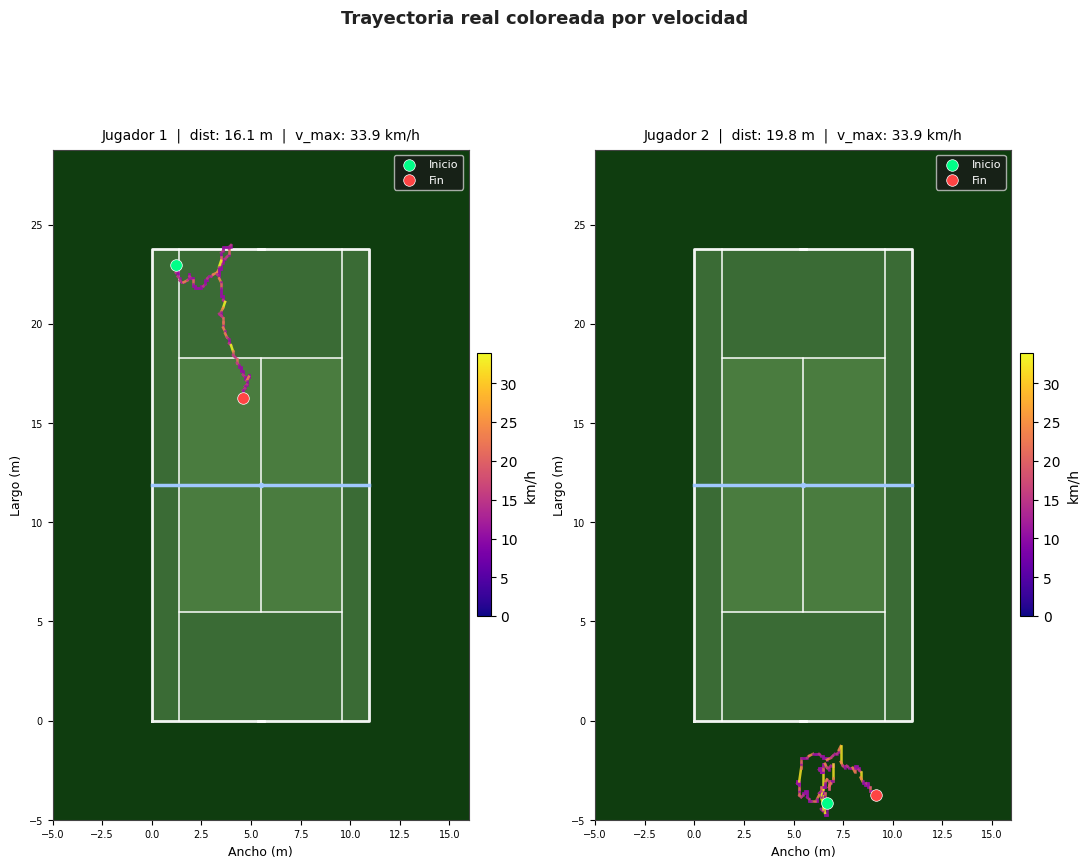

In [18]:
# Estado del minicourt
state = {
    "kps": [583.5761, 285.398, 1399.4861, 284.64185, 227.4589,
            964.61, 1741.2485, 960.8363, 684.41394, 284.69876,
            415.58276, 963.08, 1296.5673, 284.66074, 1555.0704,
            960.94586, 647.89606, 380.19016, 1330.48, 379.2586,
            510.56137, 724.38025, 1461.5251, 723.2181, 987.23376,
            379.89435, 986.083, 723.3773],
    "frame_height": 1080,
    "frame_width":  1920,
    "origin": [20, 780]
}

mc = build_minicourt(state)

plot_trajectories(df, mc, margin=5.0)

## 9. Heatmap de posición en cancha

In [19]:

def plot_heatmaps(df: pd.DataFrame, margin: float = 2.0,
                  figsize_per_player: tuple = (5.5, 9),
                  bins: int = 50, sigma: float = 1.5) -> None:
    """
    Mapa de calor de posiciones de cada jugador sobre la cancha.

    Parámetros
    ----------
    df                 : DataFrame con columnas mx, my, player_id
    margin             : metros extra fuera de la cancha visibles
    bins               : resolución de la grilla del heatmap
    sigma              : suavizado gaussiano (mayor = más difuso)
    """
    players = sorted(df['player_id'].dropna().unique().astype(int).tolist())
    n = len(players)
    fw, fh = figsize_per_player
    fig, axes = plt.subplots(1, n, figsize=(fw * n, fh))
    if n == 1:
        axes = [axes]

    x_min, x_max = -margin, COURT_WIDTH  + margin
    y_min, y_max = -margin, COURT_LENGTH + margin

    for ax, pid in zip(axes, players):
        grp = (df[df['player_id'] == pid]
               .dropna(subset=['mx', 'my']))

        draw_court_matplotlib(ax, margin=margin)

        if grp.empty:
            ax.set_title(f'Jugador {pid} — sin datos', fontsize=11)
            continue

        xs = grp['mx'].values
        ys = grp['my'].values

        # Grilla 2D de densidad
        heatmap, xedges, yedges = np.histogram2d(
            xs, ys,
            bins=bins,
            range=[[x_min, x_max], [y_min, y_max]]
        )

        # Suavizado gaussiano
        heatmap = gaussian_filter(heatmap.T, sigma=sigma)

        # Normalizar 0-1 y enmascarar ceros
        heatmap = heatmap / heatmap.max()
        heatmap_masked = np.ma.masked_where(heatmap < 0.01, heatmap)

        # Overlay sobre la cancha
        ax.imshow(
            heatmap_masked,
            origin='lower',
            extent=[x_min, x_max, y_min, y_max],
            cmap='hot',
            alpha=0.65,
            aspect='auto',
            vmin=0, vmax=1,
            zorder=5
        )

        # Punto de máxima densidad
        iy, ix = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        peak_x = xedges[ix] + (xedges[1] - xedges[0]) / 2
        peak_y = yedges[iy] + (yedges[1] - yedges[0]) / 2
        ax.scatter(peak_x, peak_y, color='white', s=80, zorder=9,
                   marker='x', linewidths=2, label=f'Zona más frecuente')

        # Colorbar
        sm = plt.cm.ScalarMappable(
            cmap='hot',
            norm=mcolors.Normalize(vmin=0, vmax=1)
        )
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label('Densidad relativa', fontsize=8)
        cbar.set_ticks([0, 0.5, 1])
        cbar.set_ticklabels(['Baja', 'Media', 'Alta'])

        n_frames = len(grp)
        ax.set_title(
            f'Jugador {pid}  |  {n_frames} posiciones',
            fontsize=10, pad=8
        )
        ax.set_xlabel('Ancho (m)', fontsize=9)
        ax.set_ylabel('Largo (m)', fontsize=9)
        ax.legend(fontsize=8, loc='upper right',
                  facecolor='#1a1a1a', labelcolor='white')

    fig.suptitle('Mapa de calor — posiciones en cancha',
                 fontsize=13, fontweight='600', y=1.01)
    plt.tight_layout()
    plt.show()

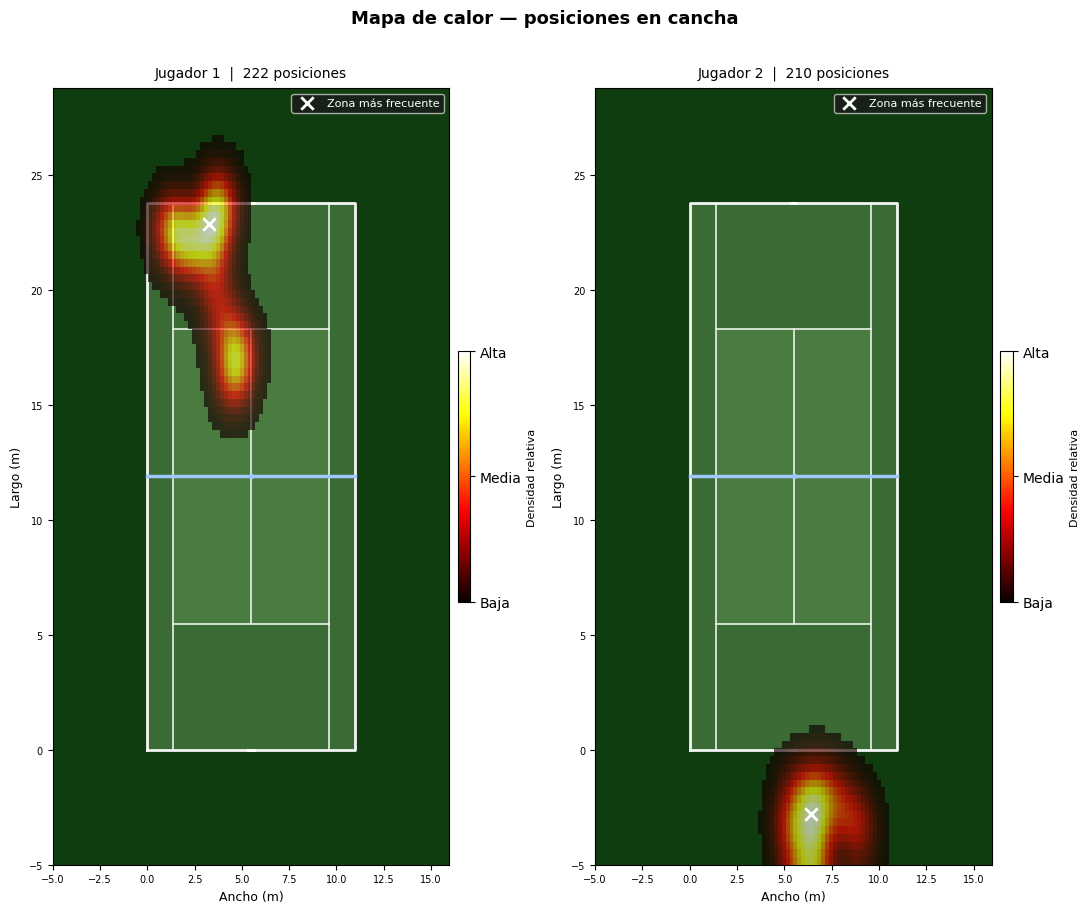

In [20]:
plot_heatmaps(df, margin=5.0, bins=100, sigma=3.0)

## 10. Zonas de la cancha => tiempo en cada zona

In [21]:
def plot_zone_time(
    df: pd.DataFrame,
    zones: dict = None,
    figsize_per_player: tuple = (4.5, 4.5),
) -> None:
    """
    Gráfico de torta con el % de tiempo que cada jugador pasa en cada zona.

    Parámetros
    ----------
    df      : DataFrame con columnas my, player_id
    zones   : dict con nombre -> (y_min, y_max) en metros.
              Si None usa las zonas defensiva/media/ofensiva por defecto,
              calculadas correctamente para cada mitad de la cancha.
    """
    if zones is None:
        zones = {
            'Defensiva':  (COURT_LENGTH * 0.66, COURT_LENGTH),   # fondo propio
            'Media':      (COURT_LENGTH * 0.33, COURT_LENGTH * 0.66),
            'Ofensiva':   (0.0,                 COURT_LENGTH * 0.33),  # red rival
        }

    zone_colors = ['#7F77DD', '#1D9E75', '#D85A30']
    players = sorted(df['player_id'].dropna().unique().astype(int).tolist())

    #  Calcular porcentajes 
    zone_data = {}
    for pid in players:
        grp  = df[(df['player_id'] == pid) & df['my'].notna()]
        total = len(grp)
        if total == 0:
            zone_data[pid] = {z: 0.0 for z in zones}
            continue
        zone_data[pid] = {
            name: round(((grp['my'] >= lo) & (grp['my'] < hi)).sum() / total * 100, 1)
            for name, (lo, hi) in zones.items()
        }

    #  Plot 
    n = len(players)
    fw, fh = figsize_per_player
    fig, axes = plt.subplots(1, n, figsize=(fw * n, fh))
    if n == 1:
        axes = [axes]

    for ax, pid in zip(axes, players):
        z      = zone_data[pid]
        values = list(z.values())
        labels = list(z.keys())

        # Excluir zonas con 0% para que no ensucien el gráfico
        filtered = [(v, l, c) for v, l, c in zip(values, labels, zone_colors) if v > 0]
        if not filtered:
            ax.set_title(f'Jugador {pid} — sin datos', fontsize=11)
            continue
        values_f, labels_f, colors_f = zip(*filtered)

        wedges, texts, autotexts = ax.pie(
            values_f,
            labels=labels_f,
            autopct='%1.1f%%',
            colors=colors_f,
            startangle=90,
            wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
        )
        for t in texts:
            t.set_fontsize(9)
        for at in autotexts:
            at.set_fontsize(8.5)
            at.set_color('white')
            at.set_fontweight('600')

        # Stats bajo el título
        grp     = df[(df['player_id'] == pid) & df['my'].notna()]
        n_frames = len(grp)
        ax.set_title(f'Jugador {pid}  |  {n_frames} frames', fontsize=11, pad=12)

    fig.suptitle('Tiempo (%) por zona de la cancha',
                 fontsize=13, fontweight='600', y=1.02)
    plt.tight_layout()
    plt.show()

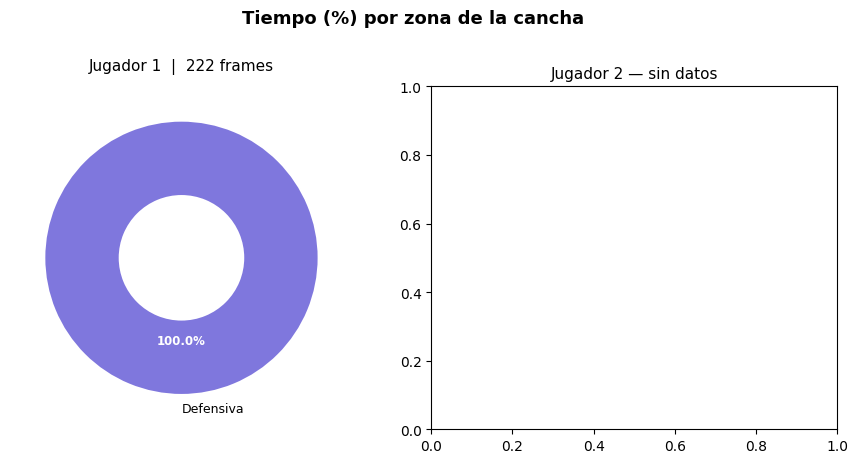

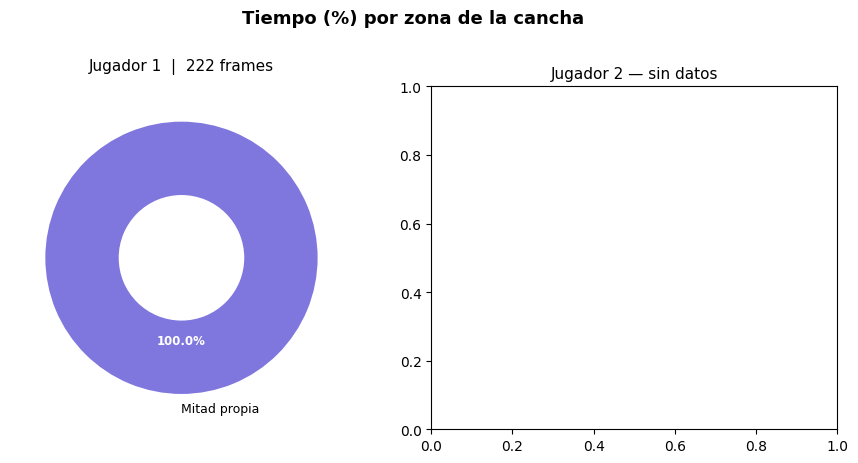

In [22]:
# Zonas por defecto (defensiva / media / ofensiva)
plot_zone_time(df)

# O con zonas personalizadas, por ejemplo dividiendo por mitad de cancha
plot_zone_time(df, zones={
    'Mitad propia': (COURT_LENGTH / 2, COURT_LENGTH),
    'Mitad rival':  (0.0,              COURT_LENGTH / 2),
})

## 11. Resumen visual final (dashboard)

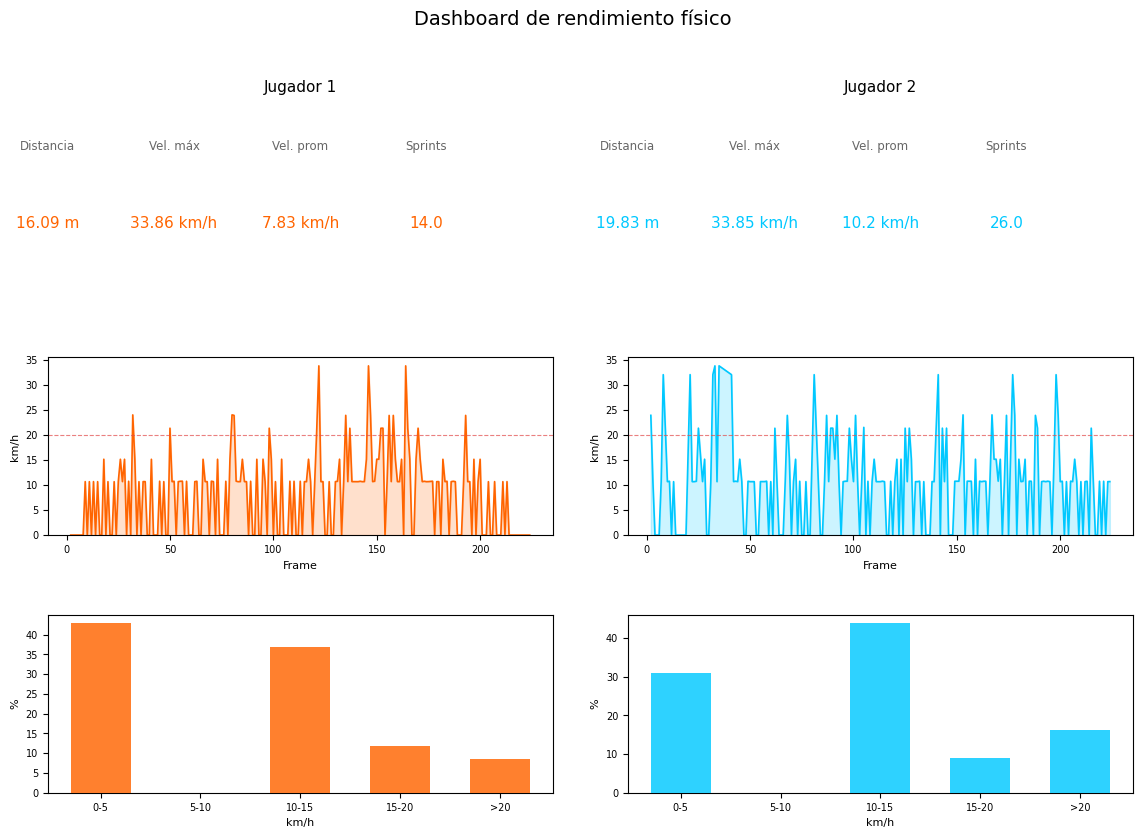

Dashboard guardado como 'dashboard_rendimiento.png'


In [23]:
fig = plt.figure(figsize=(14, 9))
fig.suptitle('Dashboard de rendimiento físico', fontsize=14, fontweight='500', y=0.98)
gs = GridSpec(3, len(players) * 2, figure=fig, hspace=0.45, wspace=0.35)

for i, pid in enumerate(players):
    color = get_color(i)
    grp = df[df['player_id'] == pid].sort_values('frame').copy()
    row = summary[summary['player_id'] == pid].iloc[0]

    # --- Tarjeta de métricas (fila 0) ---
    ax_card = fig.add_subplot(gs[0, i*2 : i*2+2])
    ax_card.set_facecolor('#f0efff' if i == 0 else '#e8f8f2')
    ax_card.set_xlim(0, 4); ax_card.set_ylim(0, 1)
    ax_card.axis('off')
    labels = ['Distancia', 'Vel. máx', 'Vel. prom', 'Sprints']
    vals   = [f"{row['dist_total_m']} m", f"{row['speed_max_kmh']} km/h",
               f"{row['speed_avg_kmh']} km/h", str(row['sprints'])]
    for j, (lbl, val) in enumerate(zip(labels, vals)):
        ax_card.text(j, 0.72, lbl, ha='center', fontsize=8.5, color='#666')
        ax_card.text(j, 0.28, val, ha='center', fontsize=11, fontweight='500', color=color)
    ax_card.set_title(f'Jugador {pid}', fontsize=11, pad=6)

    # --- Velocidad en tiempo (fila 1) ---
    ax_spd = fig.add_subplot(gs[1, i*2 : i*2+2])
    ax_spd.fill_between(grp['frame'], grp['speed_kmh'].fillna(0), alpha=0.2, color=color)
    ax_spd.plot(grp['frame'], grp['speed_kmh'], color=color, linewidth=1.2)
    ax_spd.axhline(SPRINT_THRESHOLD_KMH, color='#E24B4A', linewidth=0.8, linestyle='--', alpha=0.7)
    ax_spd.set_ylim(bottom=0)
    ax_spd.set_ylabel('km/h', fontsize=8)
    ax_spd.set_xlabel('Frame', fontsize=8)
    ax_spd.tick_params(labelsize=7)

    # --- Distrib. velocidad (fila 2) ---
    ax_hist = fig.add_subplot(gs[2, i*2 : i*2+2])
    valid_spd = grp.dropna(subset=['speed_kmh'])['speed_kmh']
    counts, _ = np.histogram(valid_spd, bins=SPEED_BINS)
    pcts = counts / counts.sum() * 100 if counts.sum() > 0 else counts
    ax_hist.bar(SPEED_LABELS, pcts, color=color, alpha=0.82, width=0.6, zorder=3)
    ax_hist.set_ylabel('%', fontsize=8)
    ax_hist.set_xlabel('km/h', fontsize=8)
    ax_hist.tick_params(labelsize=7)

#plt.savefig('dashboard_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard guardado como 'dashboard_rendimiento.png'")